In [74]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, KFold, ParameterGrid, HalvingGridSearchCV
from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score, classification_report, roc_auc_score, make_scorer, mean_squared_error
import xgboost as xgb
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm
from tqdm_joblib import tqdm_joblib


In [75]:
cars = pd.read_csv('../datasets/ml_410k.csv')

In [76]:
cars.info()

<class 'pandas.DataFrame'>
RangeIndex: 413290 entries, 0 to 413289
Data columns (total 12 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   brand               413290 non-null  str    
 1   name                413290 non-null  str    
 2   bodyType            413290 non-null  str    
 3   color               413290 non-null  str    
 4   fuelType            413290 non-null  str    
 5   year                413290 non-null  int64  
 6   mileage             413290 non-null  float64
 7   transmission        413290 non-null  str    
 8   power               413290 non-null  float64
 9   price               413290 non-null  int64  
 10  engineDisplacement  413290 non-null  float64
 11  location            413290 non-null  str    
dtypes: float64(3), int64(2), str(7)
memory usage: 37.8 MB


In [77]:
cars['name'].unique()

<StringArray>
[   '5-Series',     'S-Class',    '3-Series',  '3102 Волга',      'Celica',
      'Patrol',      'Carina',      'Soarer',        '2107',         '412',
 ...
         'DF6',  'CS85 Coupe',         'JS4',      'RX500h',  'Teramont X',
      'RX350h',       'CX-60',     'Monjaro', 'Bestune T55',          'E5']
Length: 1431, dtype: str

In [78]:
columns = [
    'name', 
    'brand', 
    'bodyType', 
    'fuelType', 
    'transmission', 
    'location'
]
cars_freq = cars.copy()
# for column in columns:
#         vc = cars_freq[column].value_counts(normalize=True, dropna=False)
#         mapping = vc.to_dict()
#         cars_freq[column + '_freq'] = cars_freq[column].map(mapping)

In [79]:
enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
cars['body_ord'] = enc.fit_transform(cars[['bodyType']])
cars['fuel_ord'] = enc.fit_transform(cars[['fuelType']]) # Not
cars['name_ord'] = enc.fit_transform(cars[['name']])
cars['brand_ord'] = enc.fit_transform(cars[['brand']]) # Not
cars['transmission_ord'] = enc.fit_transform(cars[['transmission']])
cars['location_ord'] = enc.fit_transform(cars[['location']]) # Not
cars['color_ord'] = enc.fit_transform(cars[['color']]) # Not


In [80]:
cars.info()

<class 'pandas.DataFrame'>
RangeIndex: 413290 entries, 0 to 413289
Data columns (total 19 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   brand               413290 non-null  str    
 1   name                413290 non-null  str    
 2   bodyType            413290 non-null  str    
 3   color               413290 non-null  str    
 4   fuelType            413290 non-null  str    
 5   year                413290 non-null  int64  
 6   mileage             413290 non-null  float64
 7   transmission        413290 non-null  str    
 8   power               413290 non-null  float64
 9   price               413290 non-null  int64  
 10  engineDisplacement  413290 non-null  float64
 11  location            413290 non-null  str    
 12  body_ord            413290 non-null  float64
 13  fuel_ord            413290 non-null  float64
 14  name_ord            413290 non-null  float64
 15  brand_ord           413290 non-null  float64


In [81]:
cars = cars.drop(columns=['engineDisplacement', 'name', 'brand', 'bodyType', 'fuelType', 'transmission', 'location', 'color', 'mileage'])

In [82]:
cars.info()

<class 'pandas.DataFrame'>
RangeIndex: 413290 entries, 0 to 413289
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   year              413290 non-null  int64  
 1   power             413290 non-null  float64
 2   price             413290 non-null  int64  
 3   body_ord          413290 non-null  float64
 4   fuel_ord          413290 non-null  float64
 5   name_ord          413290 non-null  float64
 6   brand_ord         413290 non-null  float64
 7   transmission_ord  413290 non-null  float64
 8   location_ord      413290 non-null  float64
 9   color_ord         413290 non-null  float64
dtypes: float64(8), int64(2)
memory usage: 31.5 MB


In [83]:
# cars = cars[cars['price'] < 1200000]

In [84]:
lower = cars['price'].quantile(0.3)
upper = cars['price'].quantile(0.7)
cars['price'] = cars['price'].clip(lower, upper)

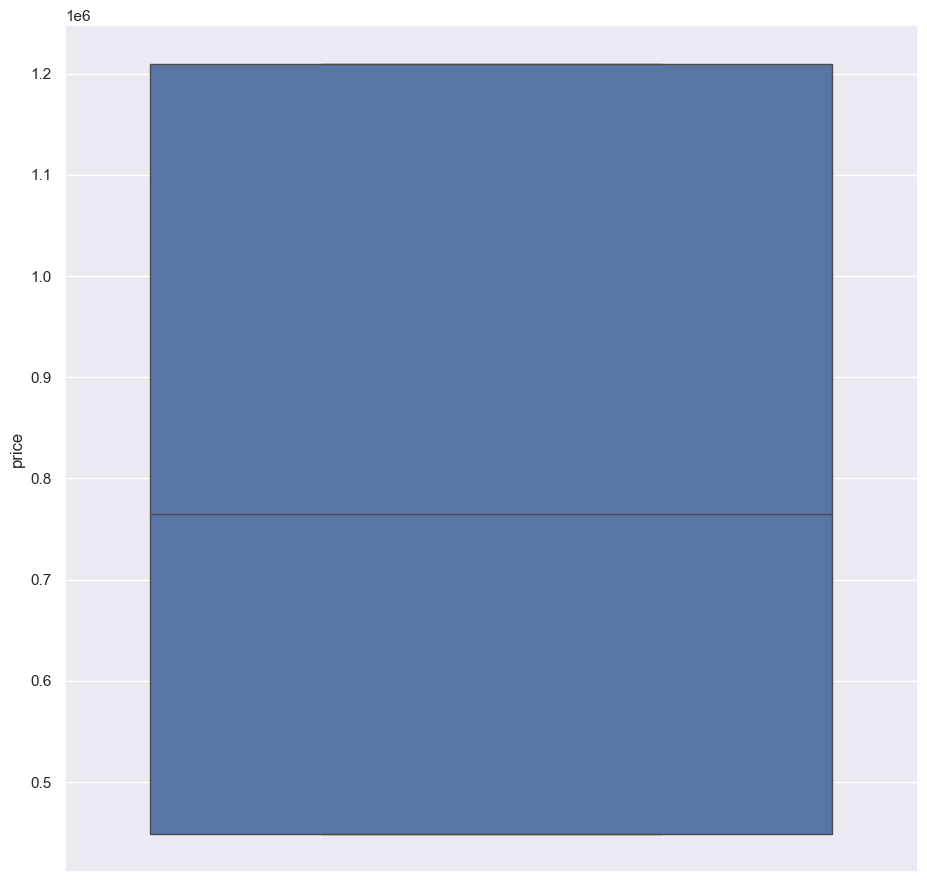

In [85]:
sns.boxplot(cars['price'])
plt.show()

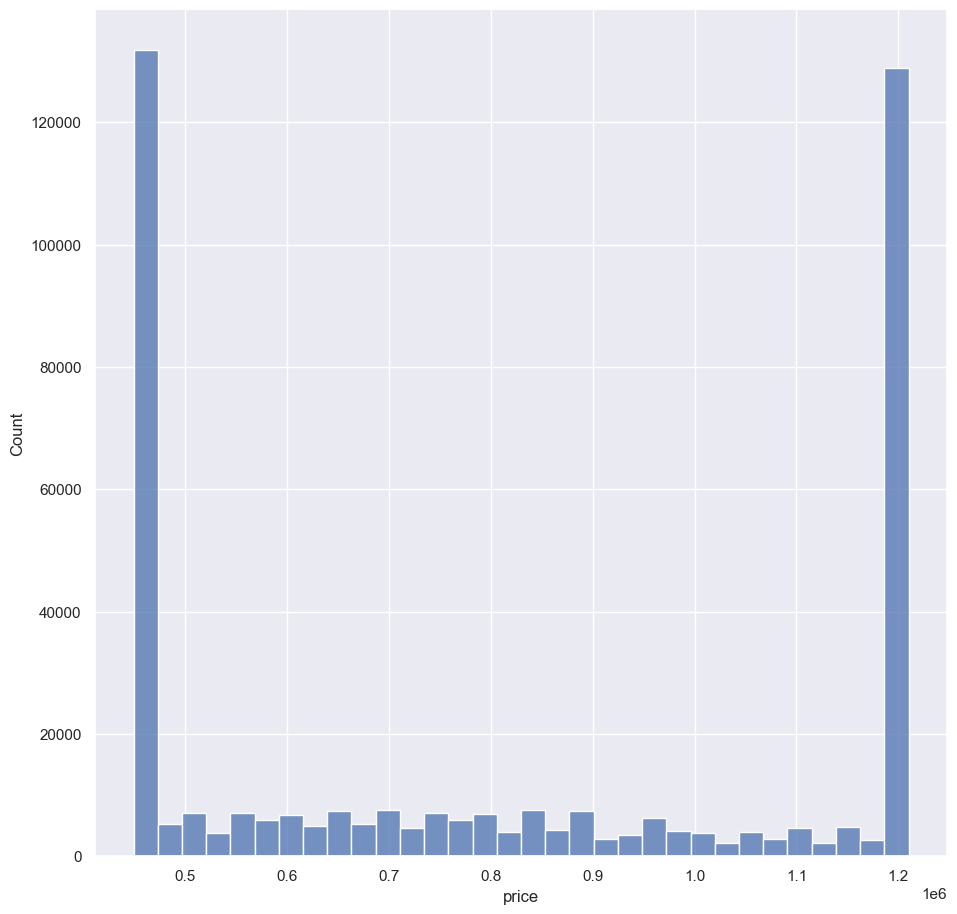

In [86]:
sns.histplot(cars['price'], bins=32)
plt.show()

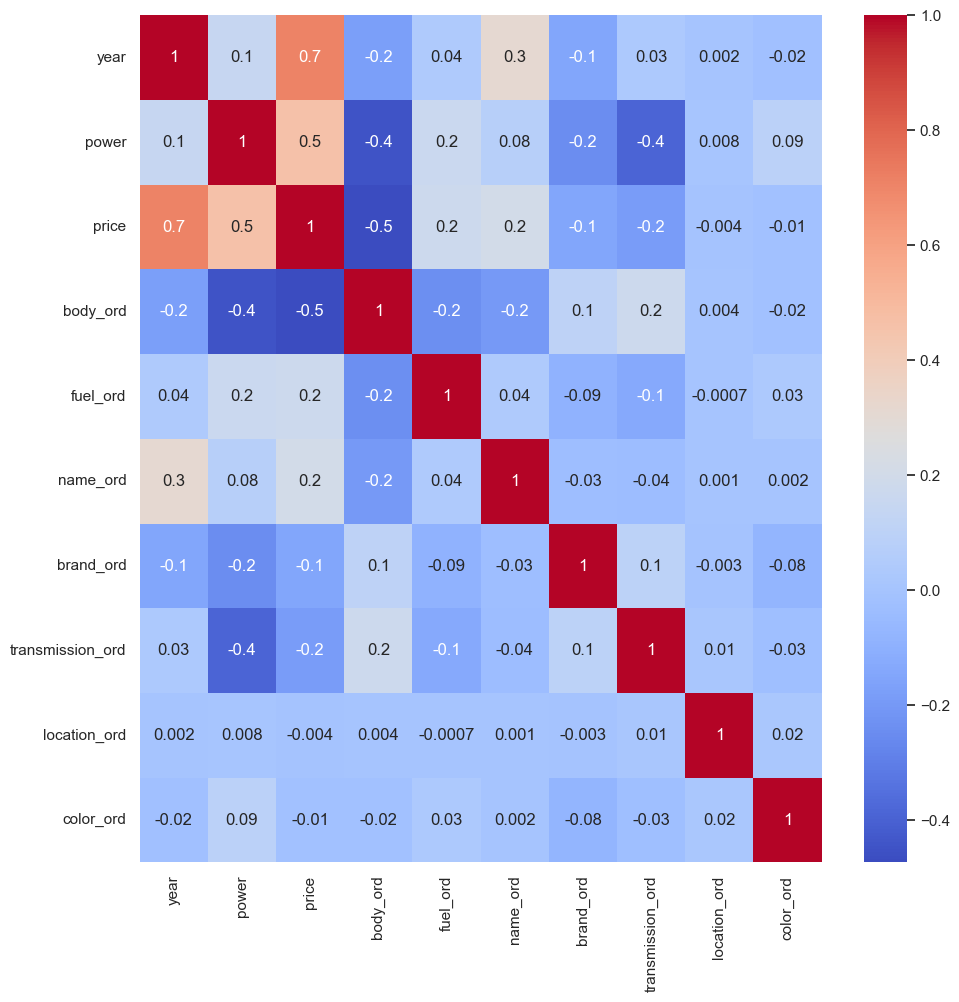

In [87]:
sns.set_theme(rc={'figure.figsize': (11, 11)})
sns.heatmap(cars.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.1g')
plt.show()

In [ ]:
X = cars.drop(columns=['price'])
y = cars['price']

scaler = StandardScaler()
X = scaler.fit_transform(X)


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

model = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.7,
    reg_alpha=0.05,
    reg_lambda=0.05,
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=100
)

[0]	validation_0-rmse:312345.19755
[100]	validation_0-rmse:79902.32393
[200]	validation_0-rmse:77189.02865
[299]	validation_0-rmse:76002.87337


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [89]:
# cv_scores = cross_val_score(model, X, y, cv=10, scoring='neg_root_mean_squared_error', n_jobs=-1, verbose=2)
# cv_scores = np.round(cv_scores, 3)
# cv_scores = cv_scores * -1
# cv_scores

In [90]:
# sns.barplot(cv_scores)
# plt.show()

In [ ]:
param_grid = {
    'n_estimators': [300, 500],
    'max_depth': [5, 10, 12],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.6, 0.7, 0.8],
    'colsample_bytree': [0.6, 0.7, 0.8],
    'reg_alpha': [0.01, 0.05, 0.1],
    'reg_lambda': [0.01, 0.05, 0.1]
}

model_obj = xgb.XGBRegressor(
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1
)

try:
    scoring = 'neg_root_mean_squared_error'
except Exception:
    from sklearn.metrics import mean_squared_error
    scoring = make_scorer(lambda y_true, y_pred: np.sqrt(mean_squared_error(y_true, y_pred)))

# model = HalvingGridSearchCV(
#     estimator=model_obj,
#     param_grid=param_grid,
#     scoring=scoring,
#     cv=3,                # 3-fold CV (можно увеличить до 5)
#     n_jobs=-1,
#     verbose=1,
#     refit=True
# )

# total_tasks = len(list(ParameterGrid(param_grid))) * 3
# with tqdm_joblib(tqdm(desc="GridSearchCV", total=total_tasks)) as progress_bar:
#     model.fit(X_train, y_train)


# best_params = model.best_params_
# best_score = model.best_score_
# print("Best params:", best_params)
# print("Best CV RMSE (approx):", best_score)

  0%|          | 0/4374 [00:00<?, ?it/s]

n_iterations: 7
n_required_iterations: 7
n_possible_iterations: 7
min_resources_: 453
max_resources_: 330632
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 1458
n_resources: 453
Fitting 3 folds for each of 1458 candidates, totalling 4374 fits


GridSearchCV:   0%|          | 0/4374 [14:15<?, ?it/s]


----------
iter: 1
n_candidates: 486
n_resources: 1359
Fitting 3 folds for each of 486 candidates, totalling 1458 fits
----------
iter: 2
n_candidates: 162
n_resources: 4077
Fitting 3 folds for each of 162 candidates, totalling 486 fits
----------
iter: 3
n_candidates: 54
n_resources: 12231
Fitting 3 folds for each of 54 candidates, totalling 162 fits
----------
iter: 4
n_candidates: 18
n_resources: 36693
Fitting 3 folds for each of 18 candidates, totalling 54 fits
----------
iter: 5
n_candidates: 6
n_resources: 110079
Fitting 3 folds for each of 6 candidates, totalling 18 fits
----------
iter: 6
n_candidates: 2
n_resources: 330237
Fitting 3 folds for each of 2 candidates, totalling 6 fits
Best params: {'colsample_bytree': 0.7, 'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 500, 'reg_alpha': 0.05, 'reg_lambda': 0.05, 'subsample': 0.8}
Best CV RMSE (approx): -89849.3046875


In [92]:
y_pred = model.predict(X_test)  # TransformedTargetRegressor вернёт предсказание в исходной шкале (expm1)
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred))
mae_test = mean_absolute_error(y_test, y_pred)
r2_test = r2_score(y_test, y_pred)

print(f"Test RMSE: {rmse_test:.2f}, MAE: {mae_test:.2f}, R2: {r2_test:.4f}")

Test RMSE: 89903.73, MAE: 54488.61, R2: 0.9233
